In [259]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
sns.set_theme()


from sklearn.datasets import fetch_openml


# Question 1

In [334]:
def load_data(random_state=None):
    X, y=fetch_openml(name='mnist_784', as_frame=True, return_X_y=True)
    X=X.values
    y=y.values.astype(int)
    data, labels=None, None
    rng=np.random.default_rng(seed=random_state)
    for i in range(10):
        subset_index=y==i
        X_, y_=X[subset_index, :], y[subset_index]
        random_index=np.arange(X_.shape[0])
        rng.shuffle(random_index)
        X_sampled, y_sampled=X_[random_index[:100]], y_[random_index[:100]]
        if data is None:
            data, labels=X_sampled, y_sampled
        else:
            data=np.concatenate((data, X_sampled))
            labels=np.concatenate((labels, y_sampled))
    return data, labels

def plot_images(data, nrows=3, ncols=3, title=''):
    fig, axes=plt.subplots(nrows,ncols)
    for i in range(nrows):
        for j in range(ncols):
            axes[i, j].imshow(data[i*ncols+j, :].reshape((28, 28)), cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title('%s %d'%(title, i*ncols+j+1))
    # plt.tight_layout()

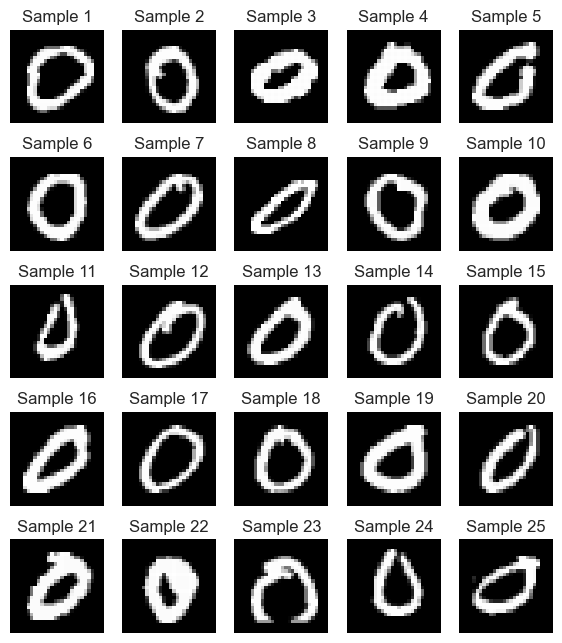

In [338]:
X, y=load_data(0)
plot_images(X, 5,5, 'Sample')
plt.gcf().set_size_inches(7, 8)

In [277]:
class PCA:
    def __init__(self):
        self.means=None
        self.evalues=None
        self.evectors=None

    def calc_cov_mat(self, X):
        X_centered=X-self.means
        return X_centered.T @ X_centered
    
    def eigen_decompose(self, X):
        evalues, evectors=np.linalg.eig(X)
        evalues, evectors=np.real(evalues), np.real(evectors)
        sort_index=evalues.argsort()[::-1]
        evalues, evectors=evalues[sort_index], evectors[:, sort_index]   
        return evalues, evectors     

    def fit(self, X):
        self.means=X.mean(axis=0)
        self.evalues, self.evectors=self.eigen_decompose(self.calc_cov_mat(X))
    
    def transform(self, X, use_pcs=None):
        X_centered=X-self.means
        if use_pcs is None:
            use_pcs=self.evectors.shape[1]
        return X_centered @ self.evectors[:, :use_pcs]
    
    def reconstruct(self, X, use_pcs=None):
        if use_pcs is None:
            use_pcs=self.evectors.shape[1]
        return (X @ self.evectors[:, :use_pcs].T) + self.means

In [339]:
pca=PCA()
pca.fit(X)

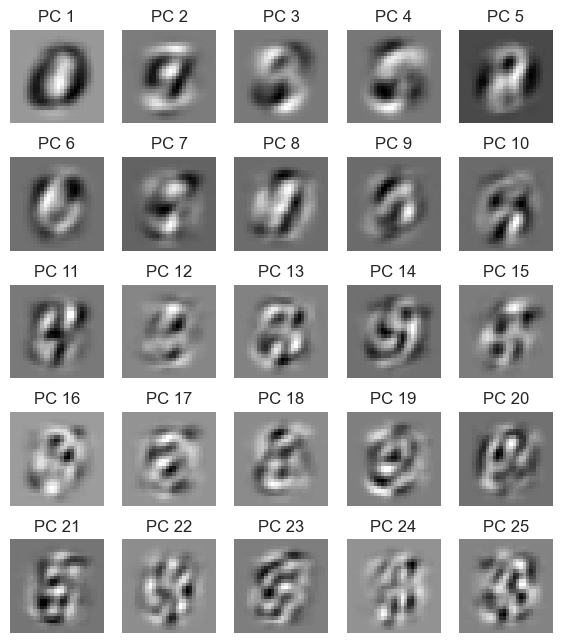

In [340]:
plot_images(pca.evectors.T, 5, 5, 'PC')
plt.gcf().set_size_inches(7, 8)


In [341]:
pca.evalues

array([ 3.43446156e+08,  2.44936687e+08,  2.21425362e+08,  1.95924557e+08,
        1.74109926e+08,  1.44303009e+08,  1.08741055e+08,  1.01997660e+08,
        9.54173013e+07,  8.48314126e+07,  7.58699561e+07,  6.74399682e+07,
        6.17744905e+07,  5.65314935e+07,  5.56732849e+07,  4.95314383e+07,
        4.71235087e+07,  4.64966631e+07,  4.14387111e+07,  3.93136883e+07,
        3.83489956e+07,  3.45407871e+07,  3.34721500e+07,  3.15898858e+07,
        3.05082923e+07,  3.00096325e+07,  2.98498960e+07,  2.77265167e+07,
        2.63048317e+07,  2.37630708e+07,  2.32565996e+07,  2.23758464e+07,
        2.07513029e+07,  1.97825443e+07,  1.86963465e+07,  1.84562007e+07,
        1.76281958e+07,  1.69965469e+07,  1.64930163e+07,  1.61179919e+07,
        1.57926311e+07,  1.49989813e+07,  1.46559189e+07,  1.43850546e+07,
        1.36277613e+07,  1.32435282e+07,  1.28111570e+07,  1.24776282e+07,
        1.16459751e+07,  1.15048544e+07,  1.05994614e+07,  1.04311529e+07,
        1.01789745e+07,  

In [ ]:
def plot_for_pcs(nrows, ncols, use_image, for_pcs, model, X):
    fig, axes=plt.subplots(nrows,ncols, figsize=(6, 6))
    for i in range(nrows):
        for j in range(ncols):
            X_compressed=model.transform(X[use_image], for_pcs[i*ncols+j])
            X_recon=model.reconstruct(X_compressed, for_pcs[i*ncols+j])
            axes[i, j].imshow(X_recon.reshape((28, 28)), cmap='gray')
            axes[i, j].axis('off')
            try:
                axes[i, j].set_title('Using %d PCs'%(for_pcs[i*ncols+j]))
            except TypeError:
                axes[i, j].set_title('Using All PCs')
    # plt.tight_layout()

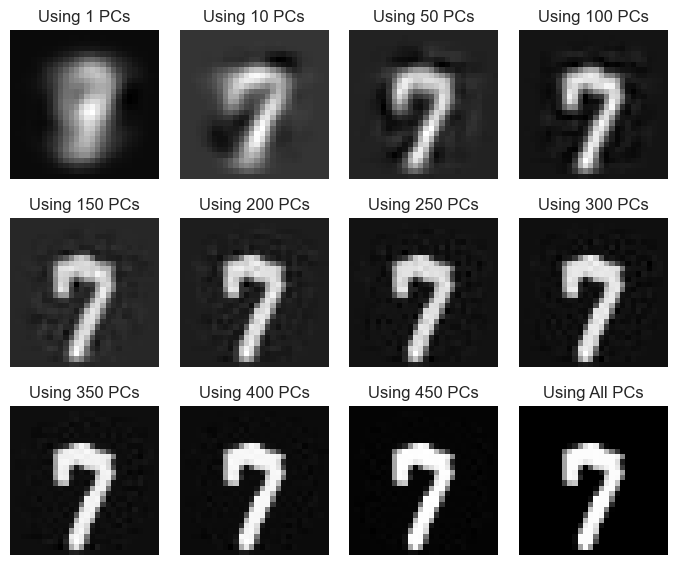

In [345]:
plot_for_pcs(3, 4, 703, [1, 10, 50, 100, 150, 200, 250, 300, 350, 400, 450, None], pca, X)
plt.gcf().set_size_inches(7, 6)

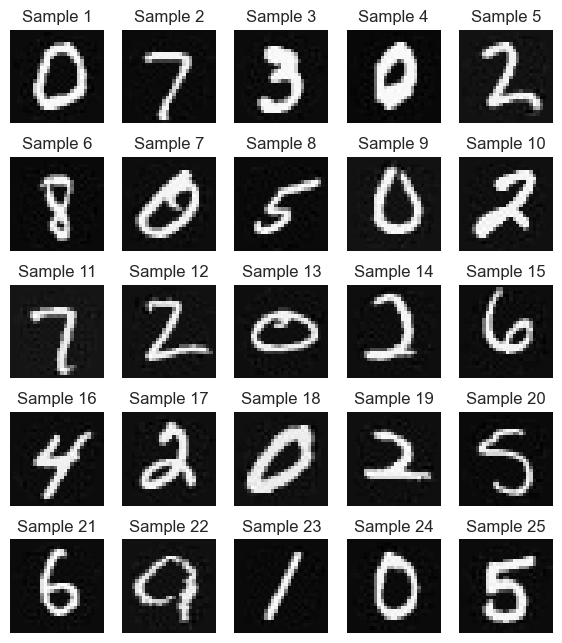

In [351]:
X_compressed=pca.transform(X, 350)
X_recon=pca.reconstruct(X_compressed, 350)
plot_images(X_recon[np.random.choice(X_recon.shape[0], 500)], 5, 5, 'Sample')
plt.gcf().set_size_inches(7, 8)

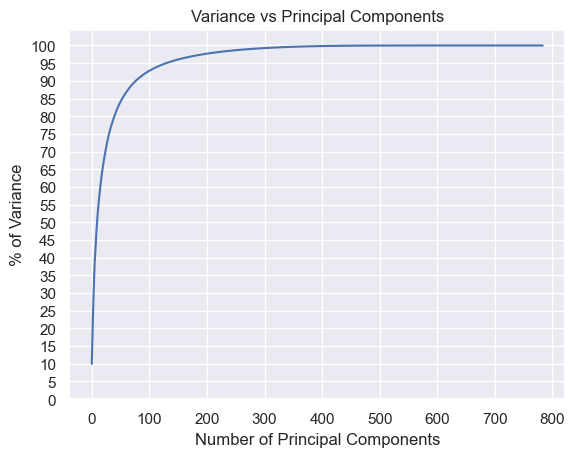

In [357]:
plt.plot((pca.evalues/pca.evalues.sum()).cumsum()*100)
ax=plt.gca()
ax.set_yticks(np.arange(105, step=5))
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('% of Variance')
ax.set_title('Variance vs Principal Components');

# Question 2

In [288]:
data=pd.read_csv('cm_dataset_2.csv', header=None)
X=data.values
X

array([[ -1.2061 ,  -2.5268 ],
       [ -3.7038 ,   0.33831],
       [  4.3444 ,   0.96302],
       ...,
       [ -2.8458 , -14.469  ],
       [-11.173  ,  -7.4088 ],
       [ -2.3857 , -13.212  ]])

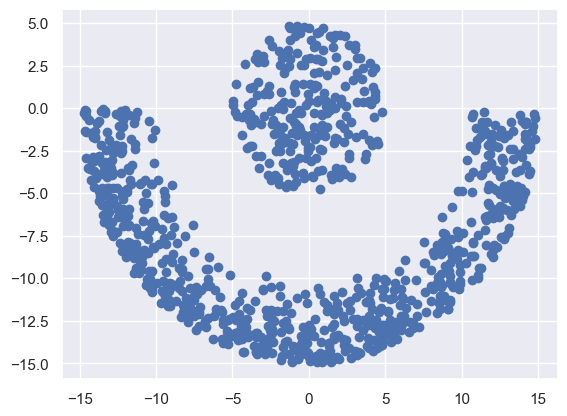

In [289]:
plt.scatter(data[0], data[1])

In [290]:
class KMeans:
    def __init__(self, n_clusters, random_state=None, max_iter=1000):
        self.n_clusters=n_clusters
        self.assignments=None
        self.means=None
        self.errors=[]
        self.random_state=random_state
        self.max_iter=max_iter
    
    def initialize(self, X):
        rng=np.random.default_rng(self.random_state)
        self.means=X[rng.choice(X.shape[0], self.n_clusters), :].reshape((self.n_clusters, 1, -1))
        self.assignments=None
        self.errors=[]
    
    def assign_clusters(self, X):
        return np.linalg.norm((X - self.means), axis=2).argmin(axis=0)
        
    def update_means(self, X):
        new_means=[]
        for cluster in range(self.n_clusters):
            new_means.append(X[self.assignments==cluster, :].mean(axis=0))
        self.means=np.array(new_means).reshape((self.n_clusters, 1, -1))

    def error(self, X):
        differences= X - self.means[self.assignments, : , :].reshape((-1, X.shape[1]))
        return np.linalg.norm(differences, axis=1).sum()

    def fit(self, X):
        self.initialize(X)
        for i in range(self.max_iter):
            new_assignment=self.assign_clusters(X)
            if (self.assignments!=new_assignment).sum() == 0:
                self.errors.append(self.error(X))
                break
            else:
                self.assignments=new_assignment
                self.errors.append(self.error(X))
                self.update_means(X)
    

    def plot_clusters(self, X, clusters_colors):
        assignment=self.assign_clusters(X)
        fig, axes=plt.subplots(1, 2)
        axes[0].plot(self.errors)
        axes[0].set_xlabel('Iterations', fontsize='large')
        axes[0].set_ylabel('Error', fontsize='large')
        axes[0].set_title('Iteration vs Error')

        axes[1].scatter(X[:, 0], X[:, 1], cmap=colors.ListedColormap(clusters_colors), c=assignment)
        axes[1].set_xlabel('$x_1$', fontsize='large')
        axes[1].set_ylabel('$x_2$', fontsize='large')
        axes[1].set_title('Cluster Assignments', fontsize='large')
        
    def plot_voronoi(self, X, cluster_colors):
        ax=plt.axes()
        points_x=np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
        points_y=np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
        mesh=np.meshgrid(points_x, points_y)
        df=np.column_stack((mesh[0].flatten(), mesh[1].flatten()))
        
        clusters=self.assign_clusters(df)
        ax.scatter(df[:, 0], df[:, 1], s=10, marker='.', c=clusters, 
                cmap=colors.ListedColormap(cluster_colors), alpha=0.7)
        
        clusters=self.assign_clusters(X)
        ax.scatter(X[:, 0], X[:, 1], c=clusters, cmap=colors.ListedColormap(cluster_colors), edgecolors='k')
        ax.set_xlabel('$x_1$', fontsize='large')
        ax.set_ylabel('$x_2$', fontsize='large')
        ax.set_title('Cluster Assignments', fontsize='large')
        


### Part 1

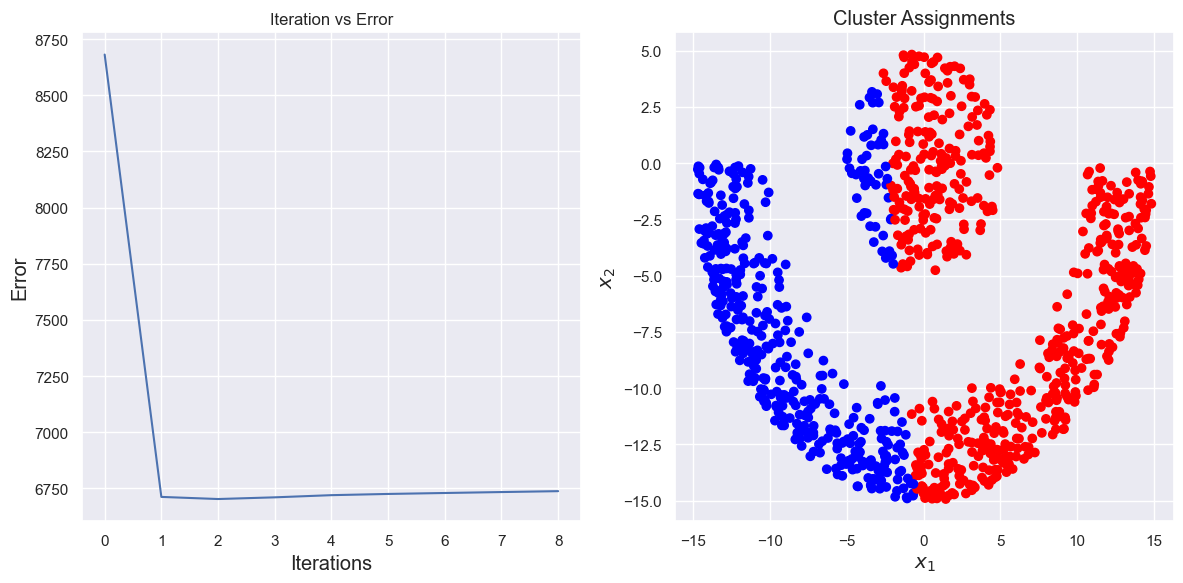

In [ ]:
# 0, 100, 400, 200, 500
km=KMeans(2, 500, 1000)
km.fit(X)
km.plot_clusters(X, ['red', 'blue'])
plt.gcf().set_size_inches(12, 6)
plt.tight_layout()

### Part 2

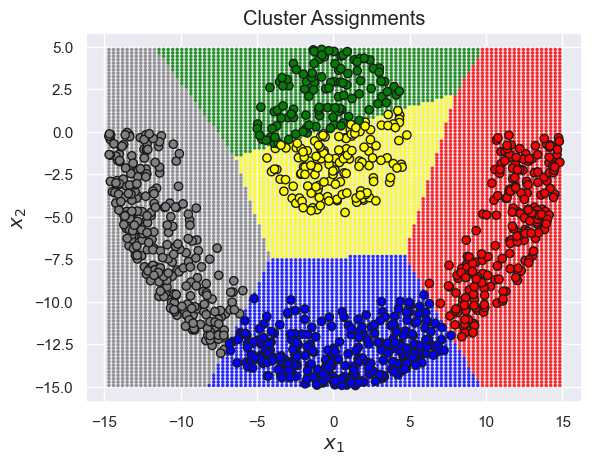

In [308]:
km=KMeans(5, 3, 1000)
km.fit(X)
km.plot_voronoi(X, ['red', 'gray', 'blue', 'yellow', 'green'])